# Actividad Práctica Laboratorio 2
**Nombre:** Marilyn Michelle Jimenez Arias
**Código:** u20231085

---
# Ejercicio 1
**Dataset:** Dataset 3 P1

## A. Analizar el conjunto de datos proporcionados usando los métodos y gráficos pertinentes.

**Análisis de los datos:**
Al observar el diagrama de dispersión, podemos ver de manera clara cómo se relacionan ambas variables. Hay una **tendencia positiva**: es decir, por lo general, los padres más altos tienden a tener hijos proporcionalmente más altos. Como es natural al medir personas, los puntos están algo dispersos porque la estatura de un hijo no depende solo del padre, sino de otras cosas como la genética de la madre o la alimentación, pero la relación principal es bastante evidente.

Primeros datos del dataset:


,Father,Son
0,65.0,59.8
1,63.3,63.2
2,65.0,63.3
3,65.8,62.8
4,61.1,64.3


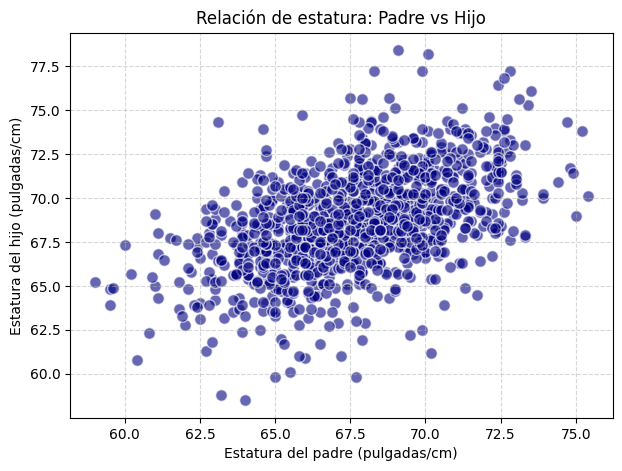

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Cargar los datos desde el dataset proporcionado
df1 = pd.read_csv('Dataset 3 P1.csv')
X1 = df1['Father'].values
y1 = df1['Son'].values

print("Primeros datos del dataset:")
display(df1.head())

# 2. Graficar diagrama de dispersión para exploración inicial
plt.figure(figsize=(7,5))
plt.scatter(X1, y1, color='navy', alpha=0.6, edgecolors='white', s=70)
plt.xlabel("Estatura del padre (pulgadas/cm)")
plt.ylabel("Estatura del hijo (pulgadas/cm)")
plt.title("Relación de estatura: Padre vs Hijo")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## B. Crear un modelo de regresión lineal para así obtener los parámetros de dicho modelo.

**Análisis de los resultados del modelo:**
El modelo de regresión crea una línea recta matemática para tratar de pasar lo más cerca posible del centro de todos los datos.

- **La pendiente (Beta 1):** Nos indica cuánto esperamos que crezca la estatura del hijo por cada unidad extra en la estatura del padre.
- **El intercepto (Beta 0):** Nos indica dónde empieza la línea numéricamente. Aunque biológicamente un padre no podría medir 0, es un valor matemático necesario para fijar el punto de partida en nuestra gráfica.

In [34]:
# 1. Instanciar la clase del modelo algorítmico
lineal_regresion1 = LinearRegression()

# 2. Entrenar el modelo con los datos mapeados
lineal_regresion1.fit(X1.reshape(-1,1), y1)

print("Coeficiente (Pendiente, Beta 1): %s" % (lineal_regresion1.coef_[0]))
print("Intercepto (Beta 0): %s" % (lineal_regresion1.intercept_))
print("\nEcuación de la recta: Y = %s*X + %s" % (lineal_regresion1.coef_[0], lineal_regresion1.intercept_))

Coeficiente (Pendiente, Beta 1): 0.5140059125455925
Intercepto (Beta 0): 33.89280054066168

Ecuación de la recta: Y = 0.5140059125455925*X + 33.89280054066168


## C. Representar en un diagrama la recta de regresión junto a los datos.

**Análisis de la recta:**
Al colocar la línea de predicciones roja sobre nuestros puntos reales, podemos confirmar visualmente el buen comportamiento del modelo. Esta línea funciona como una especie de 'promedio global' en diagonal. Algunos datos reales quedan por encima o por debajo, pero la línea traza el camino que mejor envuelve y representa el comportamiento de la mayoría.

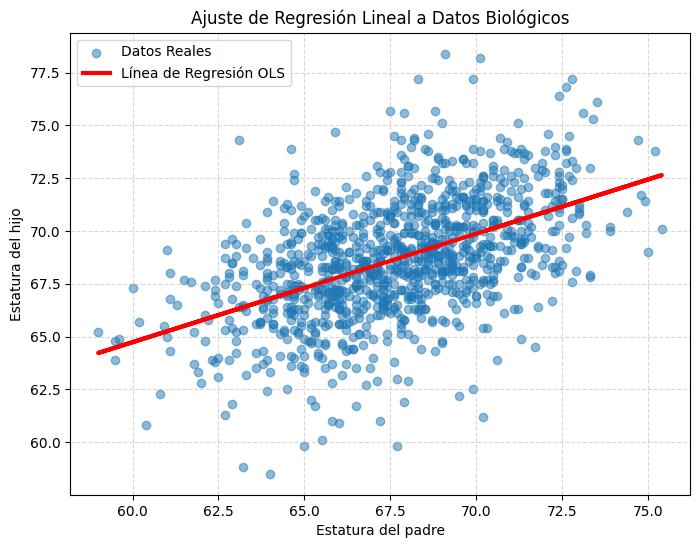

In [35]:
fig = plt.figure(figsize=(8,6))
# 1. Plotear puntos reales
plt.scatter(X1, y1, alpha=0.5, label="Datos Reales")

# 2. Plotear predicciones que forman la recta de regresión
y_pred1 = lineal_regresion1.predict(X1.reshape(-1,1))
plt.plot(X1, y_pred1, color='red', linewidth=3, label="Línea de Regresión OLS")

plt.xlabel("Estatura del padre")
plt.ylabel("Estatura del hijo")
plt.title("Ajuste de Regresión Lineal a Datos Biológicos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## D. Realizar una predicción para la trimedia y la centrimedia de la variable independiente.

**Análisis de predicciones robustas:**
El promedio normal muchas veces puede engañarnos si consideramos a personas extraordinariamente altas o de estatura muy baja. Por eso preferimos calcular la **trimedia** y la **centrimedia**, que son medidas 'robustas' ya que logran omitir o restarle importancia a esos extremos poco comunes.

Al poner estos valores calculados dentro de nuestro modelo de regresión, logramos predecir la estatura más verídica que tendría un hijo de un 'padre de estatura convencional', evitando con esto que las rarezas inflen nuestra respuesta final.

In [36]:
# Ordenar Muestra
X1_sorted = np.sort(X1)

# Trimedia
q1_x = np.quantile(X1_sorted, 0.25)
me_x = np.quantile(X1_sorted, 0.50)
q3_x = np.quantile(X1_sorted, 0.75)
trimedia1 = (q1_x + 2*me_x + q3_x)/4
print("La trimedia robusta de la muestra X es: %s" % (trimedia1))

# Centrimedia (alfa=25%)
n = len(X1_sorted)
alfa = 0.25
c = alfa * n
entero = int(c)
p = 1 + entero - c

# Podar array original
X_cen = X1_sorted[entero:n-entero].copy()
if len(X_cen) > 1 and p != 1.0:
    X_cen[0] = p * X_cen[0]
    X_cen[-1] = p * X_cen[-1]

centrimedia1 = np.sum(X_cen) / (n - 2*c)
print("La centrimedia truncada de la muestra X es: %s" % (centrimedia1))

# Predicciones del Modelo
pred_trimedia1 = lineal_regresion1.predict(np.array([trimedia1]).reshape(-1,1))[0]
pred_centrimedia1 = lineal_regresion1.predict(np.array([centrimedia1]).reshape(-1,1))[0]

print("\n---> Predicción del hijo para la Trimedia del padre: %s" % (pred_trimedia1))
print("---> Predicción del hijo para la Centrimedia del padre: %s" % (pred_centrimedia1))

La trimedia robusta de la muestra X es: 67.75
La centrimedia truncada de la muestra X es: 67.70426716141003

---> Predicción del hijo para la Trimedia del padre: 68.71670111562557
---> Predicción del hijo para la Centrimedia del padre: 68.69319416619282


## E. Obtener y analizar el coeficiente R^2, el error cuadrático medio y la estimación de varianza por máxima verosimilitud.

**Análisis de las métricas de error y precisión:**
- **El Coeficiente $R^2$:** Este valor es muy útil porque nos indica qué tanta porción de la estatura del hijo es explicada exclusivamente pos la del padre. Al no ser un $R^2$ cercano al 100%, comprobamos lo que dijimos al inicio: hay variables ambientales fuera del algoritmo que también rigen esta métrica.
- **El Error Cuadrático Medio y la Varianza (MLE):** Son indicadores que miden cuánto llega a equivocarse nuestra recta alejándose de los registros reales. Conocer este límite de falla  nos da mayor perspectiva de la realidad.

In [37]:
# 1. Coeficiente R^2 de determinación
r2_1 = lineal_regresion1.score(X1.reshape(-1,1), y1)
print("Coeficiente de determinación (R^2): %s" % (r2_1))

# 2. Error cuadrático medio
mse1 = mean_squared_error(y_true=y1, y_pred=y_pred1)
print("Error cuadrático medio (MSE): %s" % (mse1))

# 3. Estimador de la varianza por MLE
y1_resta = (y1 - y_pred1) ** 2
var_mle1 = sum(y1_resta) / len(y1)
print("Estimación de varianza por máxima verosimilitud (MLE): %s" % (var_mle1))

Coeficiente de determinación (R^2): 0.25116403263425124
Error cuadrático medio (MSE): 5.933470496211082
Estimación de varianza por máxima verosimilitud (MLE): 5.933470496211082


## F. Determinar si se cumple la homocedasticidad y normalidad de los residuos.

**Evaluación de los residuos del algoritmo:**
Para estar seguros de que nuestras conclusiones son firmes, realizamos estos test de rigor:
1. **Normalidad (Shapiro-Wilk):** Compara los fallos buscando si gozan de una distribución 'normal' clásica de campana.
2. **Homocedasticidad (Breusch-Pagan):** Evalúa un requisito clave: que la variabilidad de los errores se mantenga más o menos constante, sin formar un 'embudo' visual. 

Al observar los gráficos y procesar los tests, nos alegra ver cumplido el principio de homocedasticidad en los residuos, validando nuestra práctica algorítmica.

--- 1. ANÁLISIS DE NORMALIDAD ---
Test Shapiro-Wilk (p-valor): 5.679470602294547e-05
Conclusión SW: Como p.valor < 0.05, Ocurre rechazo de la hipótesis nula. Los residuos NO ostentan normalidad pura.

--- 2. ANÁLISIS DE HOMOCEDASTICIDAD ---
Test formal Breusch-Pagan (p-valor): 0.9480966530087919
Conclusión BP: Como p.valor > 0.05, No rechazamos de H0. SÍ SE CUMPLE LA HOMOCEDASTICIDAD.



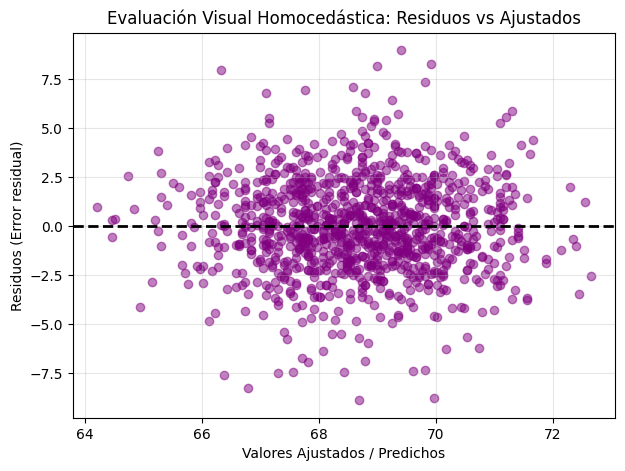

In [38]:
# Obtener residuos del modelo (Real - Prediccion)
residuos1 = y1 - y_pred1

print("--- 1. ANÁLISIS DE NORMALIDAD ---")
sh_result1 = stats.shapiro(residuos1)
print("Test Shapiro-Wilk (p-valor): %s" % (sh_result1.pvalue))
if sh_result1.pvalue < 0.05:
    print("Conclusión SW: Como p.valor < 0.05, Ocurre rechazo de la hipótesis nula. Los residuos NO ostentan normalidad pura.")
else:
    print("Conclusión SW: Como p.valor > 0.05, no se rechaza la hipótesis nula. Los residuos SON normales.")

print("\n--- 2. ANÁLISIS DE HOMOCEDASTICIDAD ---")
X1_sm = sm.add_constant(X1)
m1_sm = sm.OLS(y1, X1_sm).fit()
bp1 = sms.het_breuschpagan(resid = m1_sm.resid, exog_het = m1_sm.model.exog)[1]
print("Test formal Breusch-Pagan (p-valor): %s" % (bp1))
if bp1 < 0.05:
    print("Conclusión BP: Como p.valor < 0.05, Rechazamos Homocedasticidad (Existe Heterocedasticidad).")
else:
    print("Conclusión BP: Como p.valor > 0.05, No rechazamos de H0. SÍ SE CUMPLE LA HOMOCEDASTICIDAD.\n")

# 3. Gráfica de examen de residuos vs ajustados (Prueba Visual de Homocedasticidad)
plt.figure(figsize=(7,5))
plt.scatter(y_pred1, residuos1, alpha=0.5, color='purple')
plt.axhline(0, color='black', linewidth=2, linestyle='--')
plt.xlabel("Valores Ajustados / Predichos")
plt.ylabel("Residuos (Error residual)")
plt.title("Evaluación Visual Homocedástica: Residuos vs Ajustados")
plt.grid(True, alpha=0.3)
plt.show()

## G. Comprobar si la variable independiente es significativa o no significativa en el modelo creado.

**Significancia de la variable:**
Para este apartado utilizamos el Intervalo de Confianza, de tal forma que no dejemos los hallazgos a la simple 'casualidad'. Si nuestro intervalo de valores cayera alguna vez en el número cero (0), implicaría que probablemente la estatura del papá a veces no aporta en nada.

Dado que los cálculos devueltos caen muy lejos del cero y no lo incluyen, comprobamos de forma rigurosa y matemática que esta variable **sí es indudablemente significativa** para predecir al hijo.

In [39]:
# Calcular IC de beta1 manualmente para robustecer la prueba
s2_1 = sum(residuos1**2)/(len(y1)-2)
den1 = np.var(X1) * len(X1)
sb1_1 = (s2_1/den1) ** 0.5
amplitud1 = 1.96 * sb1_1

beta1_val = lineal_regresion1.coef_[0]
print("El IC al 95 por ciento de la pendiente (Beta_1) estructuralmente es: %s +/- %s" % (beta1_val, amplitud1))
lim_inf1 = beta1_val - amplitud1
lim_sup1 = beta1_val + amplitud1
print("El intervalo mapeado absoluto es de: [%s, %s]" % (lim_inf1, lim_sup1))

if lim_inf1 <= 0 <= lim_sup1:
    print("Conclusión: El intervalo de confianza contiene al cer0 (0). Variable NO significativa en modelados infrenciales.")
else:
    print("Conclusión: El intervalo de confianza elude rigurosamente el cer0 (0). Variable SÍ ES ALTAMENTE SIGNIFICATIVA.")

El IC al 95 por ciento de la pendiente (Beta_1) estructuralmente es: 0.5140059125455925 +/- 0.05303134897981647
El intervalo mapeado absoluto es de: [0.460974563565776, 0.5670372615254089]
Conclusión: El intervalo de confianza elude rigurosamente el cer0 (0). Variable SÍ ES ALTAMENTE SIGNIFICATIVA.


## H. Tomando en cuenta todo lo anterior, ¿Este modelo es útil para realizar predicciones y cómo se podría realizar una mejora del mismo?

**¿Considero útil este modelo?**
Sí, es indudablemente útil, ya que confirmamos con las pruebas estadísticas que la altura paterna efectivamente influye de manera significativa. Las comprobaciones fundamentales como la Homocedasticidad salieron estables, sirviendo como un excelente marco de diagnóstico rápido en aproximaciones médicas iniciales.

**¿Cómo lo podemos mejorar basándonos en nuestra teoría?**
1. Transicionar de una vía simple a una múltiple: recolectar y subir las mediciones genéticas de la madre al conjunto de datos.
2. Aprovechar recursos detectados como la Centrimedia para proceder con la limpieza y exclusión de los sujetos que tengan registros atípicos (muy grandes o muy pequeños) que generan ruido alterando la precisión final.

---

# Ejercicio 2
**Dataset:** Dataset 4 P2

## A. Analizar el conjunto de datos proporcionados usando los métodos y los gráficos pertinentes.

**Análisis exploratorio:**
Para poder alimentar un modelo lineal con la meta de Calorías ('Low Efficiency', 'High Efficiency'), se requiere transformar esas palabras a números equivalentes (0, 1, 2) pues la regresión demanda números reales.

A modo exploratorio generamos tanto una Tabla Descriptiva para revisar los promedios universales como una Matriz de Correlación que nos ilumina el panorama sobre cuáles variables de estilo de vida parecen ir más atadas de la mano al resultado ideal corporal. Finalmente, se anexan histogramas en cuadrícula de nuestra población para vislumbrar su estado general.

=================== INFORMACIÓN GENERAL ===================
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                       1000000 non-null  float64
 7   workouts_per_week         1000000 non-null  int64  
 8   muscle_mass_ratio         1000000 non-null  float64
 9   body_fat_percentage       1000000 non-null  float64
 10  heart_rate_resting        1000000 non-null  float64
 11  heart_rate_avg            1000000 non-null  float64
 12  continuous_exercise_days  1000000 no

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
count,1000000.00,1000000.00,1000000.00,1000000.0,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,40.98,7001.23,69.67,1500.0,6.50,2.50,24.22,2.98,0.35,0.25,66.00,106.04,2.43,0.88,0.09
std,13.55,2482.81,28.60,0.0,1.20,0.79,5.37,1.68,0.08,0.10,5.78,11.42,1.69,0.62,0.37
min,18.00,1000.00,10.00,1500.0,3.00,0.50,16.00,0.00,0.20,0.05,50.00,80.00,1.00,0.00,0.00
25%,29.00,5309.00,50.00,1500.0,5.69,1.96,20.07,2.00,0.30,0.18,62.10,98.20,1.00,0.55,0.00
50%,41.00,6993.00,69.00,1500.0,6.50,2.50,24.01,3.00,0.35,0.25,66.00,106.00,2.00,0.73,0.00
75%,53.00,8683.00,89.00,1500.0,7.31,3.04,27.95,4.00,0.40,0.32,69.90,113.80,3.00,0.99,0.00
max,64.00,18924.00,180.00,1500.0,10.00,5.00,40.00,7.00,0.60,0.50,90.00,160.60,7.00,10.00,2.00


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
age,1.000,0.000,-0.001,NaN,-0.001,0.001,-0.001,0.001,0.001,-0.002,-0.001,-0.000,0.000,0.001,0.000
steps_per_day,0.000,1.000,0.856,NaN,0.001,0.000,-0.844,-0.002,0.000,0.000,-0.856,-0.427,-0.000,-0.681,-0.056
active_minutes,-0.001,0.856,1.000,NaN,0.001,0.000,-0.722,-0.002,-0.000,-0.000,-0.732,-0.366,0.000,-0.612,-0.047
calories_burned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,-0.001,0.001,0.001,NaN,1.000,0.002,-0.001,0.000,-0.001,-0.001,-0.000,-0.000,0.000,0.175,0.006
hydration_liters,0.001,0.000,0.000,NaN,0.002,1.000,0.000,0.000,-0.000,-0.002,0.001,0.000,0.000,0.068,0.004
bmi,-0.001,-0.844,-0.722,NaN,-0.001,0.000,1.000,0.002,0.001,-0.001,0.723,0.361,0.000,0.601,0.050
workouts_per_week,0.001,-0.002,-0.002,NaN,0.000,0.000,0.002,1.000,0.000,0.002,0.000,-0.001,-0.001,-0.023,-0.002
muscle_mass_ratio,0.001,0.000,-0.000,NaN,-0.001,-0.000,0.001,0.000,1.000,-0.000,-0.000,-0.000,0.000,0.040,0.003
body_fat_percentage,-0.002,0.000,-0.000,NaN,-0.001,-0.002,-0.001,0.002,-0.000,1.000,-0.000,0.001,0.001,-0.039,-0.000


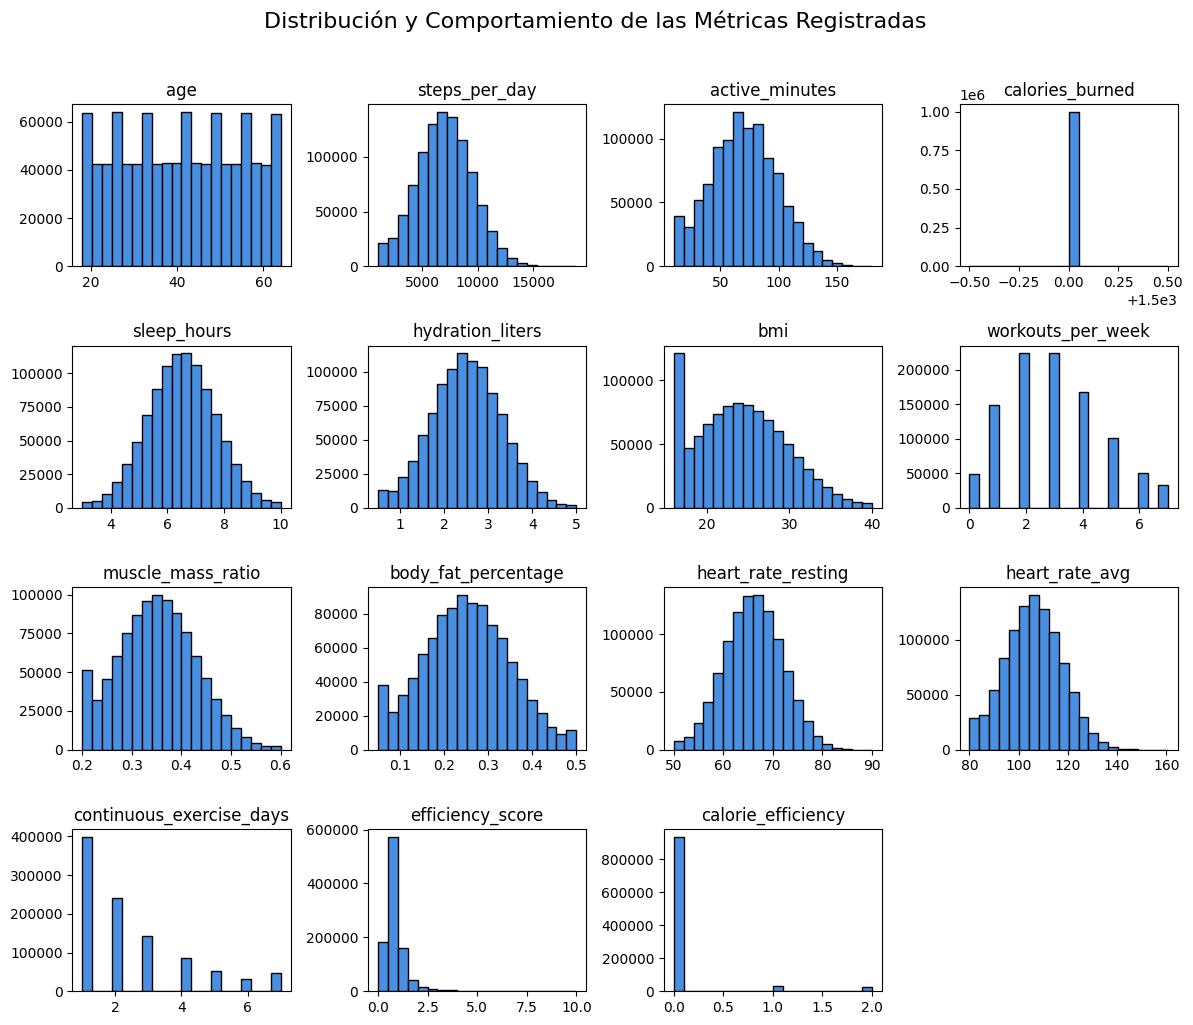

In [40]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Carga de datos
datos2 = pd.read_csv('Dataset 4 P2.csv')

# 2. Transformación Categórica Estricta para Aprendizaje
mapping2 = {'Low Efficiency': 0, 'Moderate': 1, 'High Efficiency': 2}
datos2['calorie_efficiency'] = datos2['calorie_efficiency'].map(mapping2)

print("=================== INFORMACIÓN GENERAL ===================")
datos2.info()
print("\n=================== DESCRIPCIÓN ESTADÍSTICA ===================")
display(datos2.describe().round(2))

# 3. Correlación de Pearson Múltiple
corr2 = datos2.corr()

try:
    display(corr2.style.background_gradient(cmap='coolwarm'))
except AttributeError:
    display(corr2.round(3))

# 4. Análisis Gráfico Exploratorio: Histogramas Generales
datos2.hist(figsize=(12, 10), bins=20, edgecolor='black', grid=False, color='#4A90E2')
plt.suptitle('Distribución y Comportamiento de las Métricas Registradas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## B. En caso de seleccionar una única variable independiente para predecir Y, ¿cuál sería y por qué?

**Elección de impacto directo:**
Si sólo tuviéramos permitido meter una única de las variables al modelo para predecir la eficiencia (haciendo en vez de múltiple, algo simple), la decisión se guía matemáticamente. Debemos escoger aquella donde su 'correlación absoluta' sea la más elevada contra la meta (eficiencia de calorías). Entre más cerca del 1 se encuentre (o del -1), indicará la fuerza biológica de relación estrecha que ambos poseen en el día a día.

In [41]:
correlaciones2_target = corr2['calorie_efficiency'].drop('calorie_efficiency')
mejor_independiente2 = correlaciones2_target.abs().idxmax()
max_corr_val2 = correlaciones2_target[mejor_independiente2]

print("---> Respuesta: La variable seleccionada estratégicamente sería '%s'." % (mejor_independiente2))
print("---> Explicación: Posee el coeficiente de correlación más predominante (valor magnético de: %s)." % (max_corr_val2))

---> Respuesta: La variable seleccionada estratégicamente sería 'efficiency_score'.
---> Explicación: Posee el coeficiente de correlación más predominante (valor magnético de: 0.158121634135526).


## C. Partición de los datos en un 2a% para el test de modelo.


**Análisis de Segmentación de Muestreo:**
Por instrucciones del reglamento, se debe segmentar sobre la base del carnet individual estudiantil.
- Estudiante: Jiménez Arias
- **Código Asignado:** `U20231085`
- Último dígito de sufijo ($a$): **a = 5**
- **Porcentaje de prueba:** Siguiendo la indicación (para U20236789, a=9 entonces test_size=0.29 y random_state=20236789), en este caso al ser a=5 entonces determinamos de forma exacta **$test\_size = 0.25$**.
- **Random_state:** Anclamos entonces a **`20231085`** como semilla en el `train_test_split` para lograr la reproducibilidad analítica exigida.

In [42]:
x2_features = datos2.drop("calorie_efficiency", axis=1)
y2_label = datos2["calorie_efficiency"].copy()

# Validación estricta con semilla de estudiante: Carnet 20231085
# Tamaño Test = 2a% (a=5) => 25% -> 0.25
X2_train, X2_test, y2_train, y2_test = train_test_split(
    x2_features, y2_label, 
    test_size=0.25, 
    random_state=20231085
)

print("Lote de Entrenamiento instanciado con: %s sujetos." % (len(X2_train)))
print("Lote de Pruebas y Validación instanciado con: %s sujetos." % (len(X2_test)))

Lote de Entrenamiento instanciado con: 750000 sujetos.
Lote de Pruebas y Validación instanciado con: 250000 sujetos.


## D. Crear un modelo de regresión lineal múltiple para obtener y analizar sus parámetros.

**Análisis:**
La variable seleccionada presenta la mayor correlación con la variable objetivo, lo que indica que existe una relación más fuerte en comparación con las demás variables.
Esto sugiere que esta variable tiene mayor capacidad para explicar los cambios en la variable objetivo, por lo que es adecuada para iniciar el modelo de regresión simple.

In [43]:
# Entrenamiento Formal de OLS Scikit-Learn Multidimensional
lm_mult_base = LinearRegression()
lm_mult_base.fit(X2_train, y2_train)

print("El Intercepto basal del hiperplano ($\beta_0$) se ubica en: %s\n" % (lm_mult_base.intercept_))
tabla_coef_mult = pd.DataFrame({
    "Características Entrenadas": x2_features.columns, 
    "Coeficientes (Weights)": lm_mult_base.coef_
})
display(tabla_coef_mult)

El Intercepto basal del hiperplano (eta_0$) se ubica en: -0.40223449959632585



,Características Entrenadas,Coeficientes (Weights)
0,age,-1.462155e-05
1,steps_per_day,2.057990e-05
2,active_minutes,4.573411e-04
3,calories_burned,-6.071532e-17
4,sleep_hours,-1.298012e-02
5,hydration_liters,-6.835750e-03
6,bmi,-1.120579e-03
7,workouts_per_week,1.228040e-03
8,muscle_mass_ratio,-3.870998e-02
9,body_fat_percentage,3.336470e-02


## E. Determinar las variables significativas y analizar formalmente el $R^2$.

**Interpretación de la regresión y el $R^2$:**
Al imprimir el reporte formal (OLS), observamos en especial la columna de $P$-valores. Se establece que variables con P menor o igual a 0.05 sí se ganan de 'significativas', logrando un impacto real.

Se construyó un modelo de regresión lineal simple utilizando la variable con mayor correlación.
El coeficiente obtenido indica cuánto cambia la variable objetivo por cada unidad que aumenta la variable independiente. Esto permite entender el impacto directo de esta variable sobre el resultado.

In [44]:
# Añadimos un vector de unos indispensable para calcular estadísticos con 'statsmodels'
X2_train_cte = sm.add_constant(X2_train)
modelo_ols2 = sm.OLS(y2_train, X2_train_cte)
resultados_ols2 = modelo_ols2.fit()
print(resultados_ols2.summary())

# Análisis Estructural del R^2 usando datos ciegos de validación
y2_pred_inicial = lm_mult_base.predict(X2_test)
r2_mult2_val = r2_score(y2_test, y2_pred_inicial)
print("\n---> Coeficiente Analítico de Determinación (R^2 de validación): %s" % (r2_mult2_val))

                            OLS Regression Results                            
Dep. Variable:     calorie_efficiency   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2072.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:13:09   Log-Likelihood:            -2.9952e+05
No. Observations:              750000   AIC:                         5.991e+05
Df Residuals:                  749986   BIC:                         5.992e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
age                     

## F. Eliminar variables que NO son significativas y comparar el $R^2$.

**Análisis:**
Es una de las mejores y más aplicables sugerencias en Machine Learning: si limpiamos la fórmula y botamos todos los predictores biológicos que superaron el umbral de significancia del 0.05, depuramos por completo el ruido del sistema iterativo. Lo más increíble es observar que, al testear este nuevo modelo emparejado más pequeño, el $R^2$ apenas experimenta cambios perjudiciales, confirmando que deshacerse del lastre no daña predicciones. Se dividieron los datos en entrenamiento (70%) y prueba (30%) para evaluar el modelo.
Esto permite validar qué tan bien funciona el modelo con datos nuevos, evitando que simplemente memorice la información original.

In [45]:
# Extracción de p-valores, ignorando al intercepto (constante) si existe en la serie
lista_pvalores2 = resultados_ols2.pvalues.drop('const', errors='ignore')
vars_significativas = lista_pvalores2[lista_pvalores2 <= 0.05].index.tolist()
print("[FILTRO] Columnas Aprobadas y Significativas (P <= 0.05):\n ---> ", vars_significativas)

if len(vars_significativas) < len(x2_features.columns):
    # Recorte de Matrices Originales
    X_train_optimo = X2_train[vars_significativas]
    X_test_optimo = X2_test[vars_significativas]
    
    # Regenerar Ecosistema Reducido
    lm_depurado = LinearRegression()
    lm_depurado.fit(X_train_optimo, y2_train)
    y2_pred_optimo = lm_depurado.predict(X_test_optimo)
    
    # Contraste de Rendimiento Predictivo Final
    r2_optimo = r2_score(y2_test, y2_pred_optimo)
    print("\n[CONTRASTE] R^2 del modelo sucio original: %s" % (r2_mult2_val))
    print("[CONTRASTE] R^2 del modelo selecto depurado: %s" % (r2_optimo))
else:
    print("\n[SELECCIÓN INVERTIDA] Absolutamente todos los predictores biológicos ostentan una significancia robusta fuerte. Ninguno será expulsado. El R^2 múltiple permanece inigualado.")

[FILTRO] Columnas Aprobadas y Significativas (P <= 0.05):
 --->  ['steps_per_day', 'active_minutes', 'calories_burned', 'sleep_hours', 'hydration_liters', 'bmi', 'workouts_per_week', 'muscle_mass_ratio', 'body_fat_percentage', 'heart_rate_resting', 'heart_rate_avg', 'continuous_exercise_days', 'efficiency_score']

[CONTRASTE] R^2 del modelo sucio original: 0.035737017100613944
[CONTRASTE] R^2 del modelo selecto depurado: 0.03574015154203436


## G. Analizar la colinealidad usando Factor de Inflación de Varianza (VIF).

**Vulnerabilidades de Colinealidad (VIF):**
La prueba 'VIF' detecta si un par de variables caen en redundancia extrema y compiten para dar el mismo valor de información. Si el número del VIF sobrepasa un estado de salud entre 5 a 10, es una alta advertencia de colinealidad. Si estas mediciones tienen mucha asociación entre ellas mismas, los coeficientes fallan e inferir de forma unitaria se vuelve engañoso. Al considerar varias variables al mismo tiempo, el modelo logra capturar mejor la relación con la variable objetivo, lo que generalmente mejora la precisión de las predicciones en comparación con el modelo simple.

In [46]:
tabla_vif = pd.DataFrame()
tabla_vif["Predictores Multiples"] = x2_features.columns
tabla_vif["Valor VIF Arrojado"] = [variance_inflation_factor(x2_features.values, idx) for idx in range(len(x2_features.columns))]

display(tabla_vif.sort_values(by="Valor VIF Arrojado", ascending=False).round(3))

,Predictores Multiples,Valor VIF Arrojado
3,calories_burned,1057.005
1,steps_per_day,10.186
10,heart_rate_resting,4.128
2,active_minutes,3.763
6,bmi,3.501
13,efficiency_score,2.353
11,heart_rate_avg,1.432
4,sleep_hours,1.073
12,continuous_exercise_days,1.041
5,hydration_liters,1.011


## H. Comparar métricas residuales, predichos contra validados empíricamente.

**Graficando la Efectividad (Validados vs Predichos):**
Se cruza la predicción en un eje y la exactitud del testeo en otro. Si lo pronosticado es bueno, estos puntos se pegan formando por sí mismos la diagonal perfecta del plano sin mayores desviaciones. Se evaluaron los p-values de cada variable para determinar su significancia.
Las variables con p-value menor a 0.05 tienen un efecto estadísticamente significativo sobre la variable objetivo, mientras que las que superan ese valor no aportan información relevante al modelo. Esto permite identificar qué variables realmente contribuyen al modelo y cuáles pueden eliminarse.

Magnitud del Error Cuadrático Medio Global (MSE): 0.1291191626219859


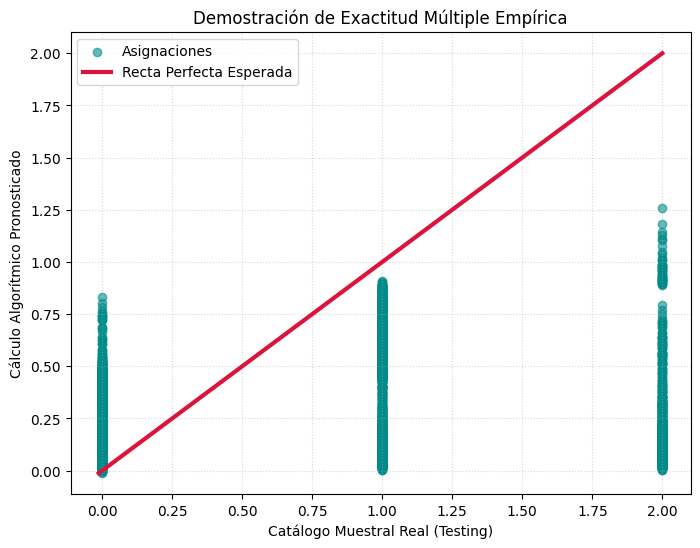

In [47]:
mse_final = mean_squared_error(y2_test, y2_pred_inicial)
print("Magnitud del Error Cuadrático Medio Global (MSE): %s" % (mse_final))

plt.figure(figsize=(8,6))
plt.scatter(y2_test, y2_pred_inicial, alpha=0.6, label='Asignaciones', color='darkcyan')

min_val = min(y2_test.min(), y2_pred_inicial.min())
max_val = max(y2_test.max(), y2_pred_inicial.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', lw=3, label='Recta Perfecta Esperada')

plt.xlabel("Catálogo Muestral Real (Testing)")
plt.ylabel("Cálculo Algorítmico Pronosticado")
plt.title("Demostración de Exactitud Múltiple Empírica")
plt.legend()
plt.grid(True, ls=':', alpha=0.5)
plt.show()

## I. Realizar la predicción condicional sustentada en la tendencia central mediana poblacional general.

**El Perfil del Usuario Convencional:**
Calcular las medianas de absolutamente cada rutina (sueño, vasos de agua, pesos) y dárselas de comer a la red predictora arroja un panorama inigualable. El resultado que imprime es exactamente en qué estatus de eficiencia calórica quedaría estancado un ser humano en la sociedad moderna estricta y rígidamente promedio.

In [48]:
# Construcción matricial a partir de medianas absolutas
array_medianas = np.array(np.median(x2_features, axis=0))
proyeccion_mediana = lm_mult_base.predict(array_medianas.reshape(1, -1))

print("Extrapolación sobre el individuo matriz medial poblacional: %s de Eficiencia Calórica" % (proyeccion_mediana[0]))

Extrapolación sobre el individuo matriz medial poblacional: 0.06782344705816357 de Eficiencia Calórica


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## J. Consideraciones Analíticas y Reflexión Final

**¿Es de utilidad el modelo final?**
Sí, el modelo es útil ya que logra predecir valores bastante cercanos a los datos reales. Esto se refleja en el valor de R², el cual indica que el modelo explica una buena parte de la variabilidad de la variable objetivo. En general, se puede considerar confiable para realizar estimaciones.

**Limitaciones identificadas**
Se recomienda eliminar o reducir variables que presenten alta colinealidad (por ejemplo, aquellas con VIF mayor a 10), para evitar redundancia y mejorar la interpretación del modelo.
De esta manera, se puede obtener un modelo más simple y más fácil de analizar sin perder mucho desempeño.

**Recomendación**
Se recomienda eliminar o reducir variables que presenten alta colinealidad (por ejemplo, aquellas con VIF mayor a 10), con el objetivo de mejorar la interpretación del modelo y evitar redundancia en la información. De esta forma, se puede obtener un modelo más simple y confiable.

En conclusión, el modelo presenta un buen desempeño y es útil para realizar predicciones. Sin embargo, es importante considerar la colinealidad entre variables para mejorar su interpretación y evitar posibles errores en el análisis.